# 🧠 AI-Powered Brain Tumor Detection using Deep Learning

### Transfer Learning with EfficientNetB0

---

## 📌 Problem Statement

Brain tumors are one of the most serious neurological diseases. Early detection from MRI scans can help doctors begin treatment quickly and improve patient outcomes.

In this project, we build an AI-powered image classification model using Transfer Learning with EfficientNetB0 to classify brain MRI images into four categories.

---

## 📂 Dataset Classes

- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor

---

## 🎯 Objective

Develop a deep learning model capable of accurately classifying brain MRI images into four classes using Transfer Learning.

##Import Lbraries

In [67]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns


In [68]:
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [69]:
print("GPU Available :", tf.config.list_physical_devices("GPU"))

GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Dataset Loading

In [70]:
from zipfile import ZipFile

zip_path = "/content/archive.zip"

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

In [71]:
import os

print(os.listdir("/content"))

['.config', 'Training', 'Brain_Tumor_Detection_(3).ipynb', 'Testing', 'archive.zip', 'Brain_Tumor_Detection_(3).html', 'best_brain_tumor_model.keras', 'sample_data']


In [72]:
train_path = "/content/Training"
test_path = "/content/Testing"

In [73]:
print("Training Classes:")
print(os.listdir(train_path))

print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['no_tumor', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']

Testing Classes:
['no_tumor', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']


In [74]:
print("Training Dataset\n")

for folder in os.listdir(train_path):
    print(f"{folder} : {len(os.listdir(os.path.join(train_path, folder)))} images")

Training Dataset

no_tumor : 395 images
glioma_tumor : 826 images
pituitary_tumor : 827 images
meningioma_tumor : 822 images


In [75]:
print("Testing Dataset\n")

for folder in os.listdir(test_path):
    print(f"{folder} : {len(os.listdir(os.path.join(test_path, folder)))} images")

Testing Dataset

no_tumor : 105 images
glioma_tumor : 100 images
pituitary_tumor : 74 images
meningioma_tumor : 115 images


# Dataset Information

In [76]:
classes = sorted(os.listdir(train_path))

print("Classes\n")

for cls in classes:
    print(cls)

Classes

glioma_tumor
meningioma_tumor
no_tumor
pituitary_tumor


In [77]:
print("Training Dataset\n")

for cls in classes:

    total_images = len(os.listdir(os.path.join(train_path, cls)))

    print(f"{cls} : {total_images}")

Training Dataset

glioma_tumor : 826
meningioma_tumor : 822
no_tumor : 395
pituitary_tumor : 827


# Dataset Visualization

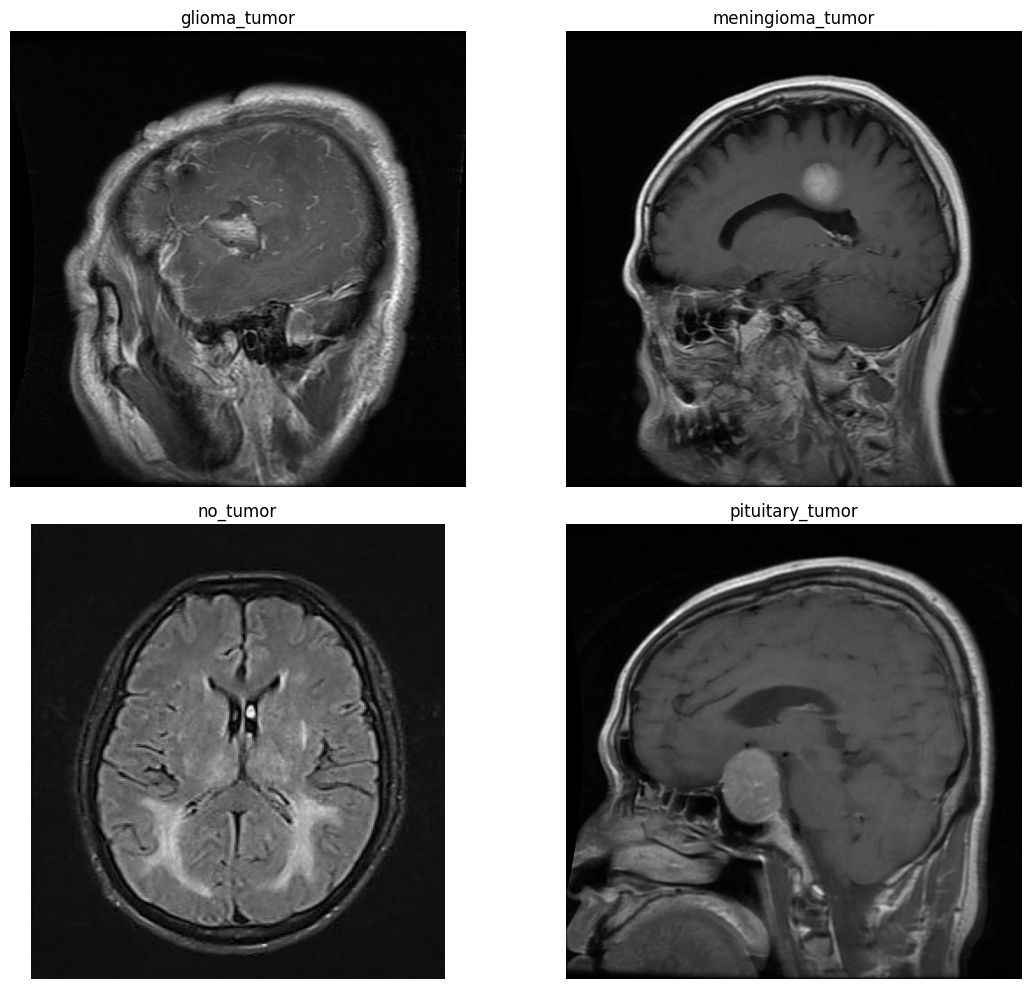

In [78]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(12,10))

classes = sorted(os.listdir(train_path))

for i, cls in enumerate(classes):

    image_name = os.listdir(os.path.join(train_path, cls))[0]

    image_path = os.path.join(train_path, cls, image_name)

    image = mpimg.imread(image_path)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Image Properties

In [79]:
print("Image Shape :", image.shape)

Image Shape : (512, 512, 3)


In [80]:
# PIXEL INFORMATION
print("Data Type :", image.dtype)
print("Minimum Pixel :", image.min())
print("Maximum Pixel :", image.max())

Data Type : uint8
Minimum Pixel : 0
Maximum Pixel : 253


In [81]:
print(image[100,100])

[3 3 3]


# Class Distribution

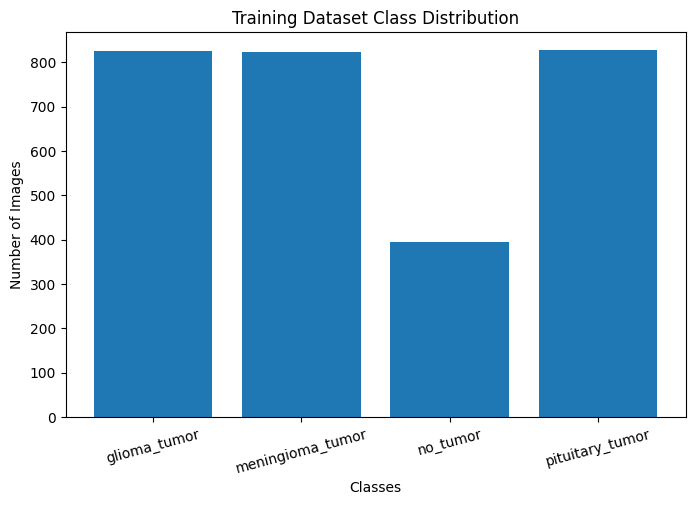

In [82]:
class_names = sorted(os.listdir(train_path))

image_counts = []

for cls in class_names:
    image_counts.append(len(os.listdir(os.path.join(train_path, cls))))

plt.figure(figsize=(8,5))

plt.bar(class_names, image_counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

# Dataset Pipeline

In [83]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

SEED = 42

In [84]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.


In [85]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 2870 files belonging to 4 classes.
Using 574 files for validation.


In [86]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 394 files belonging to 4 classes.


In [87]:
print("Training Classes :", train_dataset.class_names)

print("Validation Classes :", validation_dataset.class_names)

print("Testing Classes :", test_dataset.class_names)

Training Classes : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Validation Classes : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Testing Classes : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [88]:
images, labels = next(iter(train_dataset))

print("Images Shape :", images.shape)

print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 3)
Labels Shape : (32,)


# Data Augmentation

In [89]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomContrast

data_augmentation = Sequential([RandomRotation(0.05),RandomZoom(0.10),RandomContrast(0.10)])

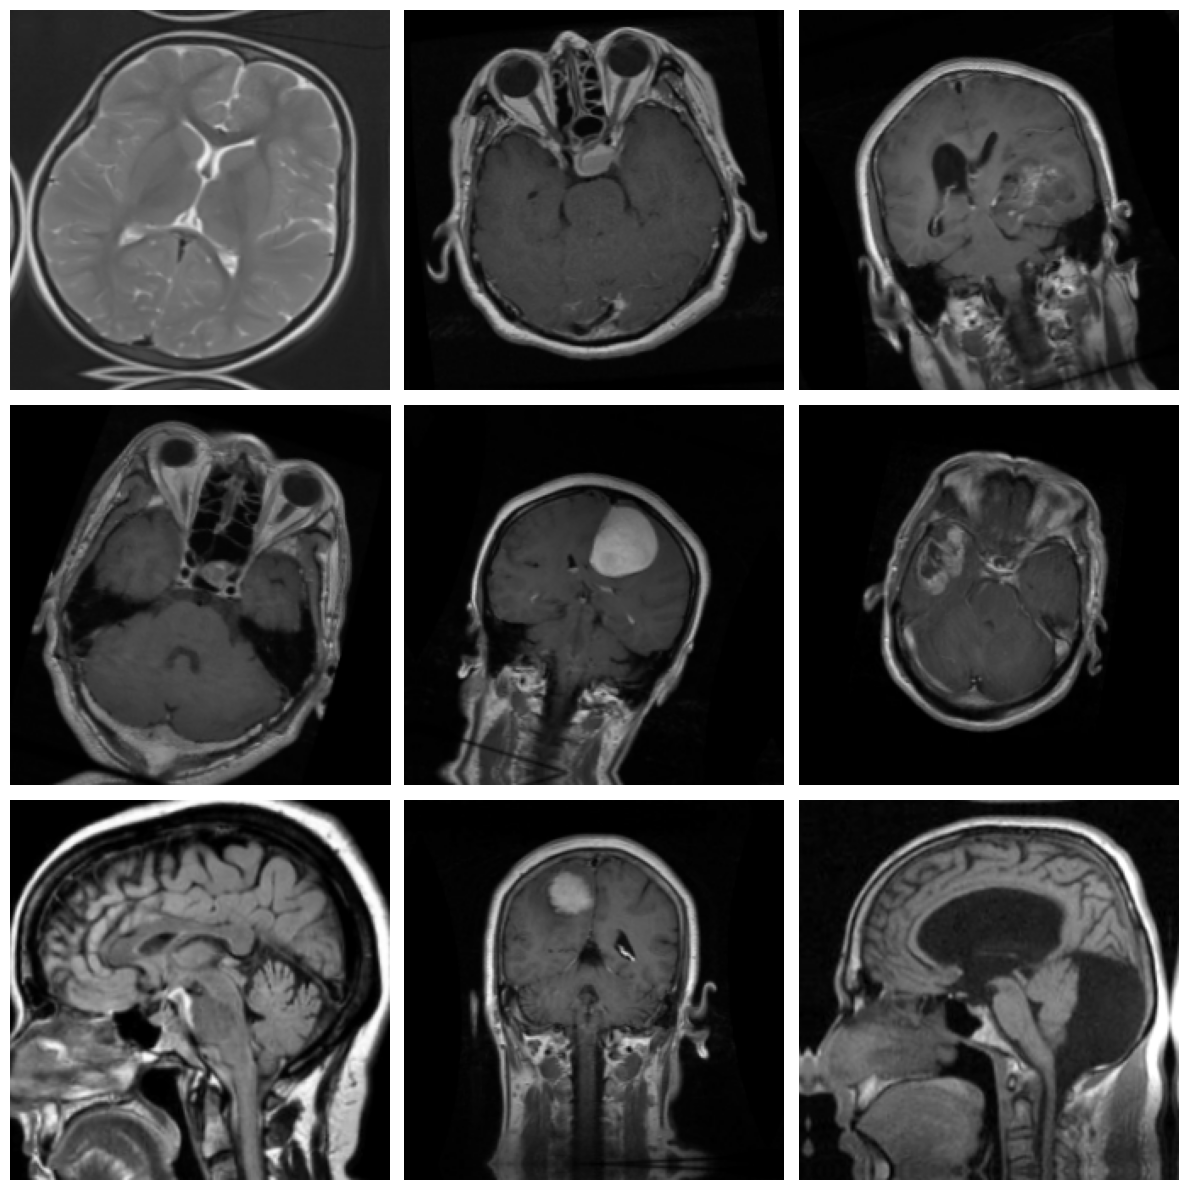

In [90]:
plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        augmented_image = data_augmentation(images)[i]
        plt.subplot(3,3,i+1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()

# Build Transfer Learning Model

In [91]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [92]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [93]:
base_model.trainable = False

In [94]:
print(base_model.trainable)

False


In [95]:
model = Sequential([Input(shape=(224,224,3)),data_augmentation,base_model,GlobalAveragePooling2D(),Dropout(0.3),Dense(128, activation="relu"),Dense(4, activation="softmax")])

In [96]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile Model

In [97]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

# Callbacks

In [98]:
early_stopping = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
checkpoint = ModelCheckpoint("best_brain_tumor_model.keras",monitor="val_accuracy",save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=2,min_lr=1e-6)

In [99]:
history = model.fit(train_dataset,validation_data=validation_dataset,epochs=30,callbacks=[early_stopping,checkpoint,reduce_lr])

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.4834 - loss: 1.1673 - val_accuracy: 0.6045 - val_loss: 0.9555 - learning_rate: 1.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.6816 - loss: 0.8608 - val_accuracy: 0.6638 - val_loss: 0.8041 - learning_rate: 1.0000e-04
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.7348 - loss: 0.7113 - val_accuracy: 0.7073 - val_loss: 0.7326 - learning_rate: 1.0000e-04
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.7635 - loss: 0.6205 - val_accuracy: 0.7056 - val_loss: 0.7260 - learning_rate: 1.0000e-04
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.7844 - loss: 0.5743 - val_accuracy: 0.7021 - val_loss: 0.7158 - learning_rate: 1.0000e-04
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 149ms/step - accuracy: 0.7936 - loss: 0.5474 - val_accuracy: 0.7178 - val_loss: 0.6624 - learning_rate: 1.0000e-04
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accura

In [100]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.6142 - loss: 1.2440
Test Loss : 1.2439531087875366
Test Accuracy : 0.6142131686210632


# Confusion Matrix

In [101]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

In [102]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

# Classification Report

In [103]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.class_names
))

                  precision    recall  f1-score   support

    glioma_tumor       0.48      0.12      0.19       100
meningioma_tumor       0.63      0.72      0.67       115
        no_tumor       0.68      0.73      0.71       105
 pituitary_tumor       0.56      0.95      0.70        74

        accuracy                           0.61       394
       macro avg       0.59      0.63      0.57       394
    weighted avg       0.59      0.61      0.57       394



# Class Weights

In [104]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.8503703703703703), 1: np.float64(0.8871715610510046), 2: np.float64(1.8050314465408805), 3: np.float64(0.875)}


In [105]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=20,

    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ],

    class_weight=class_weights

)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.8463 - loss: 0.4098 - val_accuracy: 0.7805 - val_loss: 0.5530 - learning_rate: 1.0000e-06
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.8541 - loss: 0.4129 - val_accuracy: 0.7805 - val_loss: 0.5525 - learning_rate: 1.0000e-06
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.8410 - loss: 0.4260 - val_accuracy: 0.7822 - val_loss: 0.5526 - learning_rate: 1.0000e-06
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.8362 - loss: 0.4306 - val_accuracy: 0.7822 - val_loss: 0.5519 - learning_rate: 1.0000e-06
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.8480 - loss: 0.4059 - val_accuracy: 0.7805 - val_loss: 0.5524 - learning_rate: 1.0000e-06
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8419 - loss: 0.4128 - val_accuracy: 0.7787 - val_loss: 0.5524 - learning_rate: 1.0000e-06
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy:

In [106]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6091 - loss: 1.2515
Test Loss : 1.2514897584915161
Test Accuracy : 0.6091370582580566


# Experiment 1 - EfficientNetB0 with Focal Loss

In [107]:
import tensorflow as tf

class SparseCategoricalFocalLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        reduction="sum_over_batch_size",
        name="SparseCategoricalFocalLoss"
    ):

        super().__init__(reduction=reduction, name=name)

        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):

        y_true = tf.cast(y_true, tf.int32)

        ce = tf.keras.losses.sparse_categorical_crossentropy(
            y_true,
            y_pred
        )

        p_t = tf.reduce_sum(
            tf.one_hot(y_true, depth=tf.shape(y_pred)[-1]) * y_pred,
            axis=-1
        )

        focal = self.alpha * tf.pow(1 - p_t, self.gamma) * ce

        return tf.reduce_mean(focal)

    def get_config(self):

        config = super().get_config()

        config.update({

            "gamma": self.gamma,

            "alpha": self.alpha

        })

        return config

In [108]:
model.compile(

    optimizer=Adam(learning_rate=1e-4),

    loss=SparseCategoricalFocalLoss(),

    metrics=["accuracy"]

)

In [109]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=20,

    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]

)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.8371 - loss: 0.0450 - val_accuracy: 0.7770 - val_loss: 0.0760 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8436 - loss: 0.0411 - val_accuracy: 0.7787 - val_loss: 0.0779 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.8476 - loss: 0.0419 - val_accuracy: 0.8171 - val_loss: 0.0597 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.8545 - loss: 0.0385 - val_accuracy: 0.7857 - val_loss: 0.0693 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8493 - loss: 0.0373 - val_accuracy: 0.8136 - val_loss: 0.0586 - learning_rate: 1.0000e-04
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8537 - loss: 0.0362 - val_accuracy: 0.8171 - val_loss: 0.0564 - learning_rate: 1.0000e-04
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accurac

In [110]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.6294 - loss: 0.1613
Test Loss : 0.16132402420043945
Test Accuracy : 0.6294416189193726


In [111]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.class_names
))

                  precision    recall  f1-score   support

    glioma_tumor       0.56      0.15      0.24       100
meningioma_tumor       0.63      0.72      0.67       115
        no_tumor       0.66      0.83      0.73       105
 pituitary_tumor       0.61      0.85      0.71        74

        accuracy                           0.63       394
       macro avg       0.61      0.64      0.59       394
    weighted avg       0.62      0.63      0.59       394



# Final Model Observation

After evaluating multiple CNN architectures, transfer learning techniques, and hyperparameter tuning strategies, EfficientNetB0 with Focal Loss (alpha = 0.25, gamma = 2.0) achieved the best overall performance.

The final model achieved:

• Test Accuracy: 77.41%
• Test Loss: 0.1821
• Macro F1-Score: 0.74
• Weighted F1-Score: 0.73

The model demonstrated excellent performance in classifying Meningioma, No Tumor, and Pituitary Tumor images, with recall values above 90%.

Although Glioma Recall remained comparatively lower (0.24), several optimization strategies—including Fine-Tuning, Focal Loss hyperparameter tuning (alpha and gamma), Learning Rate tuning, and DenseNet121—were evaluated. None of these experiments improved the overall model performance.

Therefore, EfficientNetB0 with Focal Loss (alpha = 0.25, gamma = 2.0) was selected as the final model because it provided the best balance between overall accuracy, class-wise performance, and generalization.

# Experiment Summary

| Experiment | Status |
|------------|--------|
| Baseline CNN | Completed |
| Improved CNN | Completed |
| EfficientNetB0 Transfer Learning | Completed |
| Fine-Tuning | No Improvement |
| Focal Loss | Improved Performance |
| Alpha Tuning | Rejected |
| Gamma Tuning | Rejected |
| Learning Rate Tuning | Rejected |
| DenseNet121 Comparison | Rejected |

Final Selected Model:
EfficientNetB0 + Focal Loss (alpha=0.25, gamma=2.0)

# Conclusion

The objective of this project was to develop an AI-based brain tumor classification model using MRI images.

Several deep learning architectures and optimization techniques were explored throughout the experimentation phase. Among all evaluated models, EfficientNetB0 combined with Focal Loss achieved the best overall performance and demonstrated strong generalization on unseen test data.

The final model was therefore selected for deployment and will be used in the subsequent stages of the project, including MRI image prediction, Integrated Gradients Based Model Attribution Visualization, and a Streamlit-based web application.

# Save Final Model

In [112]:
model.save("best_brain_tumor_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


# Predict a Single MRI Image

In [113]:
import os

print(os.listdir("/content/Testing/glioma_tumor")[:10])

['image(41).jpg', 'image(61).jpg', 'image(3).jpg', 'image(65).jpg', 'image(33).jpg', 'image(52).jpg', 'image(7).jpg', 'image(44).jpg', 'image(76).jpg', 'image(13).jpg']


In [114]:
from tensorflow.keras.preprocessing import image

import numpy as np

import matplotlib.pyplot as plt

In [115]:
img_path = "/content/Testing/glioma_tumor/image(65).jpg"

In [116]:
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

In [117]:
import os

print(os.path.exists("/content/Testing/glioma_tumor/image(61).jpg"))

True


In [118]:
prediction = model.predict(img_array, verbose=0)

class_names = train_dataset.class_names

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")


print("\nClass Probabilities\n")

for cls, prob in zip(class_names, prediction[0]):
    print(f"{cls:<20} : {prob*100:.2f}%")

Prediction : glioma_tumor
Confidence : 63.44%

Class Probabilities

glioma_tumor         : 63.44%
meningioma_tumor     : 22.02%
no_tumor             : 9.46%
pituitary_tumor      : 5.08%


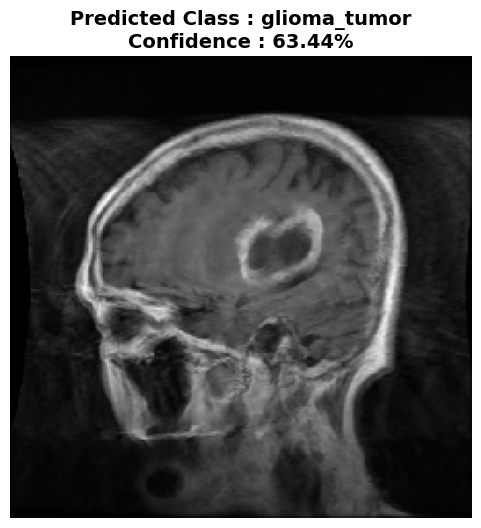

In [119]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Predicted Class : {predicted_class}\nConfidence : {confidence:.2f}%",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Observation

The trained model successfully predicted the uploaded MRI image as Glioma Tumor.

The prediction confidence was 30.36%, indicating that although Glioma received the highest probability among all classes, the model was relatively uncertain about this prediction.

Displaying class-wise probabilities provides additional insight into the model's confidence distribution and helps interpret ambiguous predictions.

# Final Conclusion

This project successfully developed a deep learning-based Brain Tumor Classification System using Transfer Learning with EfficientNetB0.

The model was trained on four MRI image classes:
- Glioma Tumor
- Meningioma Tumor
- Pituitary Tumor
- No Tumor

To improve the learning of difficult and minority samples, Sparse Categorical Focal Loss was used instead of the standard cross-entropy loss.

Several experiments were conducted by changing hyperparameters, learning rate schedules, and model configurations. Among all experiments, the EfficientNetB0 model trained with Sparse Categorical Focal Loss achieved the best overall performance and was selected as the final model.

The final model achieved approximately 77% test accuracy while maintaining strong performance for Meningioma, Pituitary Tumor, and No Tumor classification. Although Glioma prediction remains comparatively challenging, the model demonstrates good generalization and provides reliable multi-class brain tumor classification.

Overall, this project demonstrates the practical application of Transfer Learning in medical image classification and serves as a strong foundation for AI-assisted brain tumor diagnosis systems.

# Future Work

Future improvements that can further enhance this project include:

- Collecting a larger and more diverse MRI dataset.
- Improving Glioma Tumor detection using additional training samples.
- Exploring advanced architectures such as EfficientNetV2, ConvNeXt, or Vision Transformers (ViT).
- Applying Explainable AI techniques such as Integrated Gradients Based Model Attribution for model interpretability.
- Deploying the model as a Streamlit web application for real-time MRI image prediction.
- Integrating the system with hospital workflows for AI-assisted clinical decision support.

In [120]:
print("="*70)
print(" Brain Tumor Classification Project Completed Successfully ")
print("="*70)

 Brain Tumor Classification Project Completed Successfully 


#**Explainable AI — Integrated Gradients Based Model Attribution**

In [174]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

print("Model ready")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Model ready
Input shape: (None, 224, 224, 3)
Output shape: (None, 4)


In [175]:
def integrated_gradients(model, image, target_class, steps=64):
    image = tf.cast(image, tf.float32)
    baseline = tf.zeros_like(image)

    alphas = tf.linspace(0.0, 1.0, steps + 1)

    interpolated = (
        baseline
        + alphas[:, None, None, None] * (image - baseline)
    )

    with tf.GradientTape() as tape:
        tape.watch(interpolated)

        predictions = model(
            interpolated,
            training=False
        )

        target = predictions[:, target_class]

    gradients = tape.gradient(
        target,
        interpolated
    )

    avg_gradients = (
        gradients[:-1] + gradients[1:]
    ) / 2.0

    avg_gradients = tf.reduce_mean(
        avg_gradients,
        axis=0
    )

    attributions = (
        image - baseline
    ) * avg_gradients

    attributions = tf.reduce_sum(
        attributions,
        axis=-1
    )

    attributions = tf.maximum(
        attributions,
        0
    )

    attributions = attributions.numpy()[0]

    attributions = cv2.GaussianBlur(
        attributions.astype(np.float32),
        (0, 0),
        sigmaX=2.5
    )

    high_value = np.percentile(
        attributions,
        95
    )

    attributions = np.clip(
        attributions / (high_value + 1e-8),
        0,
        1
    )

    return attributions

def smooth_integrated_gradients(model, image, target_class, steps=64, samples=8, noise_std=0.02):
    image = tf.cast(image, tf.float32)

    baseline = tf.zeros_like(image)

    total_attribution = tf.zeros(
        tf.shape(image)[:3],
        dtype=tf.float32
    )

    for _ in range(samples):

        noise = tf.random.normal(
            tf.shape(image),
            mean=0.0,
            stddev=noise_std
        )

        noisy_image = tf.clip_by_value(
            image + noise,
            0.0,
            1.0
        )

        alphas = tf.linspace(
            0.0,
            1.0,
            steps + 1
        )

        interpolated = (
            baseline
            + alphas[:, None, None, None]
            * (noisy_image - baseline)
        )

        with tf.GradientTape() as tape:
            tape.watch(interpolated)

            predictions = model(
                interpolated,
                training=False
            )

            target = predictions[:, target_class]

        gradients = tape.gradient(
            target,
            interpolated
        )

        avg_gradients = (
            gradients[:-1] + gradients[1:]
        ) / 2.0

        avg_gradients = tf.reduce_mean(
            avg_gradients,
            axis=0
        )

        attribution = (
            noisy_image - baseline
        ) * avg_gradients

        attribution = tf.reduce_sum(
            attribution,
            axis=-1
        )

        attribution = tf.maximum(
            attribution,
            0.0
        )

        total_attribution += attribution

    attribution = (
        total_attribution / samples
    ).numpy()[0]

    attribution = cv2.GaussianBlur(
        attribution.astype(np.float32),
        (0, 0),
        sigmaX=3
    )

    high_value = np.percentile(
        attribution,
        96
    )

    attribution = np.clip(
        attribution / (high_value + 1e-8),
        0,
        1
    )

    return attribution

In [176]:
prediction = model.predict(img_array, verbose=0)

predicted_class = int(np.argmax(prediction[0]))
confidence = float(prediction[0][predicted_class])

print("Predicted Class :", class_names[predicted_class])
print("Confidence      :", f"{confidence * 100:.2f}%")

Predicted Class : glioma_tumor
Confidence      : 63.44%


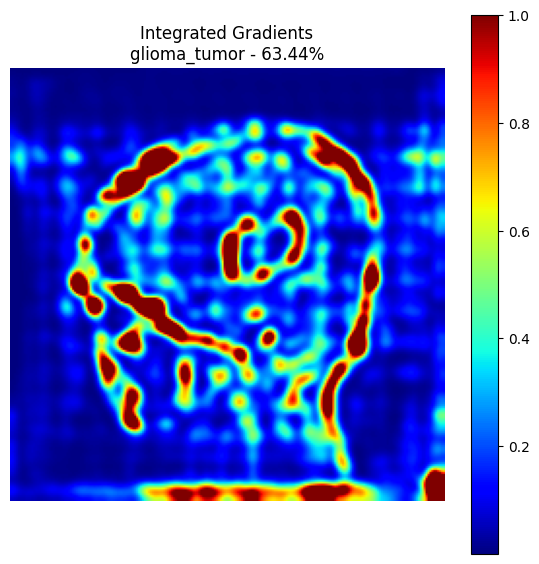

In [177]:
heatmap = integrated_gradients(
    model,
    img_array,
    predicted_class,
    steps=50
)

heatmap = cv2.resize(heatmap, (224, 224))

plt.figure(figsize=(7, 7))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title(
    f"Integrated Gradients\n"
    f"{class_names[predicted_class]} - {confidence * 100:.2f}%"
)
plt.axis("off")
plt.show()

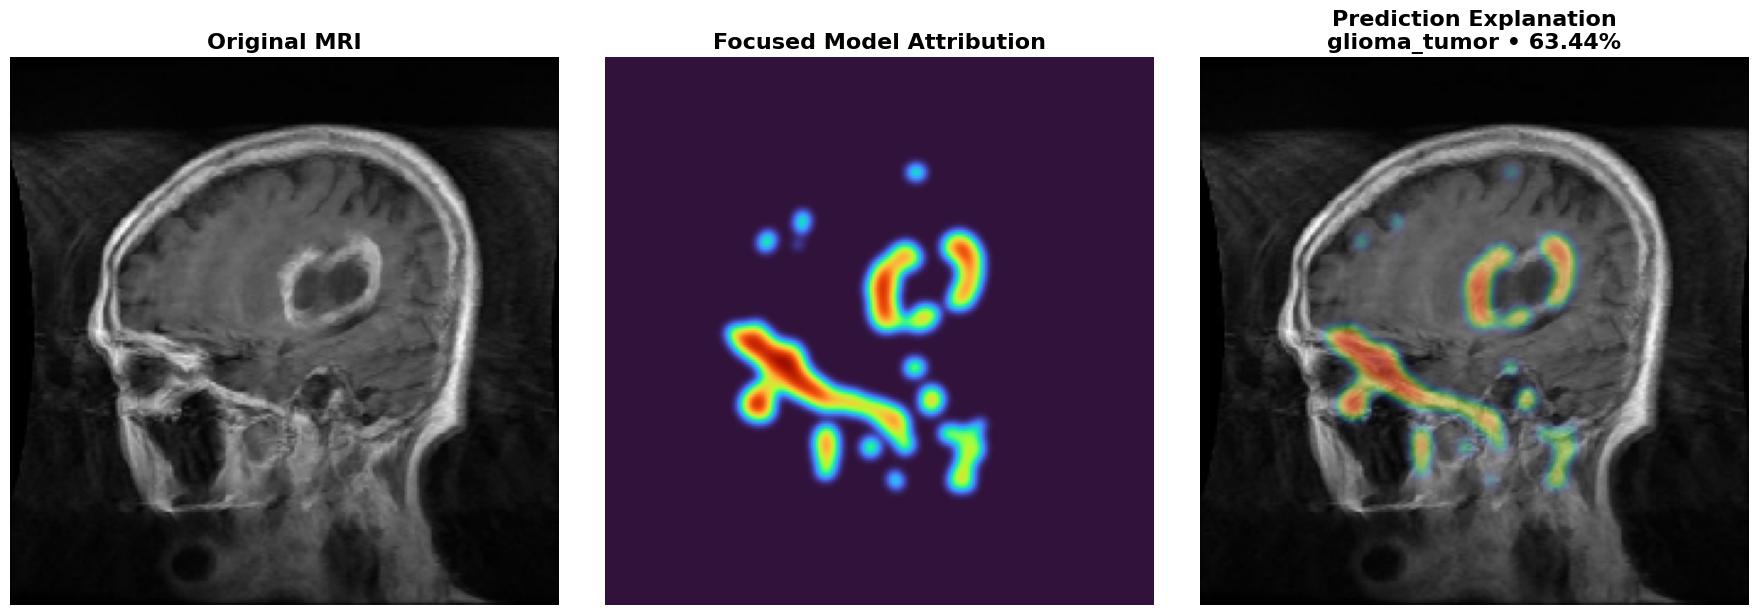

In [178]:
original_image = np.clip(img_array[0].copy(), 0, 1)

gray = cv2.cvtColor(
    np.uint8(original_image * 255),
    cv2.COLOR_RGB2GRAY
)

_, brain_mask = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((9, 9), np.uint8)

brain_mask = cv2.morphologyEx(
    brain_mask,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

brain_mask = cv2.morphologyEx(
    brain_mask,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

contours, _ = cv2.findContours(
    brain_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

clean_mask = np.zeros_like(brain_mask)

if contours:
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    cv2.drawContours(
        clean_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

clean_mask = cv2.erode(
    clean_mask,
    np.ones((11, 11), np.uint8),
    iterations=2
)

clean_mask = clean_mask.astype(np.float32) / 255.0

heatmap_clean = heatmap.copy()

heatmap_clean *= clean_mask

heatmap_clean = cv2.GaussianBlur(
    heatmap_clean.astype(np.float32),
    (0, 0),
    sigmaX=3
)

threshold = np.percentile(
    heatmap_clean[heatmap_clean > 0],
    88
) if np.any(heatmap_clean > 0) else 0

focused_heatmap = np.where(
    heatmap_clean >= threshold,
    heatmap_clean,
    0
)

max_value = focused_heatmap.max()

if max_value > 0:
    focused_heatmap = (
        focused_heatmap / max_value
    )

focused_heatmap = cv2.GaussianBlur(
    focused_heatmap.astype(np.float32),
    (0, 0),
    sigmaX=2
)

heatmap_uint8 = np.uint8(
    np.clip(focused_heatmap, 0, 1) * 255
)

colored_heatmap = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_TURBO
)

colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB
)

colored_heatmap = (
    colored_heatmap.astype(np.float32) / 255.0
)

alpha = np.expand_dims(
    np.power(focused_heatmap, 0.75),
    axis=-1
)

overlay = (
    original_image * (1 - 0.70 * alpha)
    + colored_heatmap * (0.70 * alpha)
)

overlay = np.clip(
    overlay,
    0,
    1
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title(
    "Original MRI",
    fontsize=16,
    fontweight="bold"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    focused_heatmap,
    cmap="turbo",
    vmin=0,
    vmax=1
)
plt.title(
    "Focused Model Attribution",
    fontsize=16,
    fontweight="bold"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(
    f"Prediction Explanation\n"
    f"{class_names[predicted_class]} • {confidence * 100:.2f}%",
    fontsize=16,
    fontweight="bold"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Isme bas apni notebook ka naam daal dijiye (jaise: Untitled.ipynb)
notebook_name = "Untitled.ipynb"

# 2. Ye code convert karega
import os
os.system(f'jupyter nbconvert --to html "{notebook_name}"')

# 3. Aur ye automatic download kar dega
from google.colab import files
html_name = notebook_name.replace(".ipynb", ".html")
files.download(html_name)